# Stage 3 · Step 01 — Setup and the frozen classifier

Stage 3 inserts a flow-matching transformation **in front of** a linear classifier that has
already been trained and is then held fixed:

$$z \;\xrightarrow{\ \text{FM},\ T \text{ Euler steps}\ }\; \hat z \;\xrightarrow{\ \text{frozen } W,\,b\ }\; s$$

Everything Stage 3 claims is a difference against the Stage 1 linear probe, so this step
does not train any flow. It establishes the four things the rest of the stage stands on:

1. **Recover the Stage 1 classifier.** Stage 1 saved accuracies, curves and predictions —
   but not the probe's weights. They are re-derived here and checked against Stage 1
   *exactly* before anything is built on them.
2. **Freeze it, mechanically.** `FrozenClassifier` carries `requires_grad=False` and
   refuses to leave eval mode, so the comparison cannot be corrupted by an accidental
   gradient.
3. **Start the flow at identity.** A zeroed output layer makes $v \equiv 0$, so
   $\hat z = z$ bit-for-bit and the untrained Stage 3 system *is* the Stage 1 probe.
4. **Settle the normalization question by measuring it** — Stage 3 must feed the classifier
   raw features, and this is the step that shows what happens if it does not.

## 1 · Setup

In [1]:
from __future__ import annotations

import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from cvlab.data import make_kshot_subset
from cvlab.evaluation import summarize_runs
from cvlab.features import load_features
from cvlab.plotting import ArtifactWriter, apply_style
from cvlab.probe import ProbeConfig
from cvlab3.probe import train_frozen_classifier
from cvlab3 import COMBOS, K_SHOT, SEEDS, T_STEPS, FrozenClassifier, identity_flow, transform
from cvlab3.paths import RESULTS_ROOT, STAGE1_RESULTS, describe, step_dirs

apply_style()
PLOTS, TABLES = step_dirs("01_setup_classifier")
art = ArtifactWriter(PLOTS, TABLES)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(describe())
print()
print(f"device = {DEVICE}   |   K = {K_SHOT}   |   T = {T_STEPS}   |   seeds = {SEEDS}")

Stage_3 root          : C:\Users\<user>\Project in Computer Vision\ProjectInComputerVision\Stage_3  [ok]
Work root             : C:\Users\<user>\Project in Computer Vision\ProjectInComputerVision\Stage_3\Work  [ok]
Results (Stage 3)     : C:\Users\<user>\Project in Computer Vision\ProjectInComputerVision\Stage_3\results  [ok]
Docs                  : C:\Users\<user>\Project in Computer Vision\ProjectInComputerVision\Stage_3\docs  [ok]
Stage_1 root          : C:\Users\<user>\Project in Computer Vision\ProjectInComputerVision\Stage_1  [ok]
Stage_1 feature cache : C:\Users\<user>\Project in Computer Vision\ProjectInComputerVision\Stage_1\features  [ok]
Stage_1 results       : C:\Users\<user>\Project in Computer Vision\ProjectInComputerVision\Stage_1\results  [ok]

device = cuda   |   K = 10   |   T = 4   |   seeds = (0, 1, 2)


In [2]:
# The combinations Stage 3 runs. We use one representative encoder per dataset
# (the first two); ResNet-18 on Aircraft is carried as well because it is the combination
# where Stage 1 measured the worst class separability, and therefore the most informative
# test of whether a flow can rescue a representation a linear classifier struggles with.
for encoder, dataset in COMBOS:
    bundle = load_features(encoder, dataset, "train")
    norms = bundle.features.norm(dim=1)
    print(f"{encoder:>9} / {dataset:<14} dim={bundle.features.shape[1]:>4}  "
          f"classes={len(bundle.classes):>3}  ||z||: mean {norms.mean():5.1f}  "
          f"range {norms.min():5.1f}-{norms.max():5.1f}")

 resnet18 / DTD            dim= 512  classes= 47  ||z||: mean  23.6  range   9.4- 54.3
   dinov2 / FGVC-Aircraft  dim= 384  classes=100  ||z||: mean  49.6  range  46.9- 52.0
 resnet18 / FGVC-Aircraft  dim= 512  classes=100  ||z||: mean  29.0  range  21.8- 39.9


Those norms matter later in this notebook. The features the Stage 1 probe was trained on
live at a scale of roughly **24–50**, not on the unit sphere — a fact Stage 1 step 02
measured and Stage 2 had to work around. Stage 2 L2-normalized its features because its
targets (class prototypes) are unit-norm by construction. **Stage 3 must not** — its
classifier was trained on raw features — and section 5 measures what that choice is worth.

## 2 · Recovering the Stage 1 classifier

`cvlab.probe.train_linear_probe` returns accuracy, curves and test predictions, then lets
the trained layer go out of scope — Stage 1 never needed the weights and Stage 2 used
prototypes instead. Stage 3 needs the classifier itself.

**Stages 1 and 2 are finished and published, so neither is edited.** Stage 3 carries its own
`cvlab3.probe.train_frozen_classifier`, which reproduces Stage 1's loop and additionally
returns the weights. Its hyperparameters are *not* duplicated — `ProbeConfig` is imported
from Stage 1, so the learning rate, weight decay, batch size, epoch budget and checkpoint
rule keep exactly one definition in the project.

Duplicated logic is normally a liability here. Two things stop it being one: the cell below
asserts this implementation reproduces Stage 1's published numbers exactly, and
`Stage_3/tests/test_probe_equivalence.py` runs both implementations against each other and
asserts they agree on accuracy, predictions, selected epoch and every training curve. Drift
cannot be silent.

In [3]:
stage1_runs = pd.read_csv(STAGE1_RESULTS / "linear_probe_runs.csv")
# The K column mixes integers with the literal "full", so pandas types it as object.
# Comparing it as a string is the honest way to select K = 10 rather than relying on
# a coincidence of parsing.
stage1_runs["K"] = stage1_runs["K"].astype(str)
stage1_preds = torch.load(STAGE1_RESULTS / "linear_probe_predictions.pt",
                          map_location="cpu", weights_only=False)

config = ProbeConfig()            # the Stage 1 baseline configuration, unmodified
rows, classifiers, curves = [], {}, {}

t0 = time.perf_counter()
for encoder, dataset in COMBOS:
    train_b = load_features(encoder, dataset, "train")
    val_b = load_features(encoder, dataset, "val")
    test_b = load_features(encoder, dataset, "test")
    num_classes = len(train_b.classes)

    for seed in SEEDS:
        # Same sampler, same (K, seed) -> provably the same images Stage 1 trained on.
        sub_x, sub_y = make_kshot_subset(train_b.features, train_b.labels, K_SHOT, seed)

        result = train_frozen_classifier(
            sub_x, sub_y, val_b.features, val_b.labels, test_b.features, test_b.labels,
            num_classes=num_classes, seed=seed, config=config, device=DEVICE,
        )

        key = f"{encoder}__{dataset}__K{K_SHOT}__seed{seed}"
        ref = stage1_runs[(stage1_runs["encoder"] == encoder)
                          & (stage1_runs["dataset"] == dataset)
                          & (stage1_runs["K"] == str(K_SHOT))
                          & (stage1_runs["seed"] == seed)]
        assert len(ref) == 1, f"expected exactly one Stage 1 row for {key}, got {len(ref)}"
        stage1_acc = float(ref["test_acc"].iloc[0])

        preds_match = bool(torch.equal(result.test_preds, stage1_preds[key]))
        n_diff = int((result.test_preds != stage1_preds[key]).sum())

        rows.append({
            "encoder": encoder, "dataset": dataset, "seed": seed,
            "stage1_test_acc": stage1_acc,
            "rederived_test_acc": result.test_acc,
            "abs_delta_pp": abs(result.test_acc - stage1_acc) * 100,
            "predictions_identical": preds_match,
            "n_predictions_differing": n_diff,
            "best_epoch": result.best_epoch,
            "n_train": result.n_train,
        })
        classifiers[key] = {
            "state_dict": result.state_dict,
            "encoder": encoder, "dataset": dataset, "K": K_SHOT, "seed": seed,
            "stage1_test_acc": stage1_acc, "num_classes": num_classes,
            "dim": int(train_b.features.shape[1]),
        }
        curves[key] = result.history

verify = pd.DataFrame(rows)
print(f"{len(verify)} probes retrained in {time.perf_counter() - t0:.1f}s")
verify

9 probes retrained in 30.1s


,encoder,dataset,seed,stage1_test_acc,rederived_test_acc,abs_delta_pp,predictions_identical,n_predictions_differing,best_epoch,n_train
0,resnet18,DTD,0,0.511702,0.511702,0.0,True,0,14,470
1,resnet18,DTD,1,0.515957,0.515957,0.0,True,0,37,470
2,resnet18,DTD,2,0.533511,0.533511,0.0,True,0,32,470
3,dinov2,FGVC-Aircraft,0,0.531953,0.531953,0.0,True,0,197,1000
4,dinov2,FGVC-Aircraft,1,0.516052,0.516052,0.0,True,0,178,1000
5,dinov2,FGVC-Aircraft,2,0.498050,0.498050,0.0,True,0,187,1000
6,resnet18,FGVC-Aircraft,0,0.267027,0.267027,0.0,True,0,198,1000
7,resnet18,FGVC-Aircraft,1,0.293129,0.293129,0.0,True,0,157,1000
8,resnet18,FGVC-Aircraft,2,0.276028,0.276028,0.0,True,0,161,1000


In [4]:
# The check this whole stage rests on. Anything but an exact match means the classifier
# Stage 3 freezes is not the classifier Stage 1 reported, and every delta downstream
# would be measured against the wrong baseline.
max_delta = verify["abs_delta_pp"].max()
all_preds_match = bool(verify["predictions_identical"].all())
total_differing = int(verify["n_predictions_differing"].sum())

assert max_delta == 0.0, f"accuracy drifted from Stage 1 by up to {max_delta:.6f} pp"
assert all_preds_match, f"{(~verify['predictions_identical']).sum()} runs have different predictions"

print(f"max |delta| in test accuracy vs Stage 1 : {max_delta:.2e} pp")
print(f"test predictions identical              : {all_preds_match} "
      f"({total_differing} of {len(verify) * 1880} labels differ)")
print()
print("The Stage 1 linear probe is reproduced exactly. Its weights can be trusted as the")
print("frozen classifier for the rest of Stage 3.")

max |delta| in test accuracy vs Stage 1 : 0.00e+00 pp
test predictions identical              : True (0 of 16920 labels differ)

The Stage 1 linear probe is reproduced exactly. Its weights can be trusted as the
frozen classifier for the rest of Stage 3.


In [5]:
art.table(verify, "stage1_probe_reproduction")

summary = summarize_runs(verify, ["encoder", "dataset"], "rederived_test_acc")
art.table(summary, "frozen_classifier_accuracy")
summary

  saved table -> tables/stage1_probe_reproduction.csv  (9 rows)
  saved table -> tables/frozen_classifier_accuracy.csv  (3 rows)


,encoder,dataset,mean,std,n_runs,accuracy
0,dinov2,FGVC-Aircraft,51.54,1.70,3,51.54 +/- 1.70
1,resnet18,DTD,52.04,1.16,3,52.04 +/- 1.16
2,resnet18,FGVC-Aircraft,27.87,1.33,3,27.87 +/- 1.33


## 3 · Freezing it

`FrozenClassifier` wraps $s = Wz + b$ and makes "frozen" mechanical rather than a promise:
every parameter is constructed with `requires_grad=False`, and `.train()` is overridden to
ignore requests to leave eval mode — so a parent module calling `.train()` on the whole
system cannot silently unfreeze it.

Gradient still *flows through* the layer (Strategy 1 needs to differentiate the loss back
into the flow), which is a different thing from the layer's own parameters being updated.

In [6]:
frozen = {}
for key, payload in classifiers.items():
    clf = FrozenClassifier.from_state_dict(payload["state_dict"]).to(DEVICE)
    frozen[key] = clf

probe = frozen[f"resnet18__DTD__K{K_SHOT}__seed0"]
print(probe)
print()
print("parameters requiring grad :", sum(p.requires_grad for p in probe.parameters()))
probe.train(True)
print("training mode after .train(True) :", probe.training)

# Gradient reaches an input through the layer, but never lands on W or b.
z = torch.randn(4, probe.dim, device=DEVICE, requires_grad=True)
probe(z).sum().backward()
print("gradient reaches the input       :", z.grad is not None and bool((z.grad != 0).any()))
print("gradient on classifier weight    :", probe.linear.weight.grad)

FrozenClassifier(
  dim=512, num_classes=47, frozen=True
  (linear): Linear(in_features=512, out_features=47, bias=True)
)

parameters requiring grad : 0
training mode after .train(True) : False
gradient reaches the input       : True
gradient on classifier weight    : None


In [7]:
# Re-check that the wrapped classifier still produces Stage 1's exact predictions - the
# weights survived the round trip through FrozenClassifier unchanged.
rows = []
for key, payload in classifiers.items():
    test_b = load_features(payload["encoder"], payload["dataset"], "test")
    x = test_b.features.to(DEVICE)
    with torch.no_grad():
        preds = frozen[key](x).argmax(dim=1).cpu()
    rows.append({
        "run": key,
        "acc": (preds == test_b.labels).float().mean().item(),
        "stage1_test_acc": payload["stage1_test_acc"],
        "predictions_identical": bool(torch.equal(preds, stage1_preds[key])),
    })

wrapped = pd.DataFrame(rows)
wrapped["abs_delta_pp"] = (wrapped["acc"] - wrapped["stage1_test_acc"]).abs() * 100

# The strict check is on the predictions: the frozen classifier must assign every one of
# the test images to the same class Stage 1 did. Accuracy is a deterministic function of
# those predictions, so it is checked only to float tolerance - it is recomputed here as a
# float32 reduction on the CPU, while Stage 1 reduced on the GPU, and the two can disagree
# in the last bits purely from summation order.
assert wrapped["predictions_identical"].all(), "FrozenClassifier changed the predictions"
# One float32 ULP near an accuracy of 0.5 is 2**-24 = 5.96e-08, i.e. 5.96e-06 pp - the
# same magnitude Stage 2 reported when recomputing its accuracies from stored predictions.
assert wrapped["abs_delta_pp"].max() < 1e-4, wrapped["abs_delta_pp"].max()

print(f"all {len(wrapped)} frozen classifiers reproduce Stage 1's predictions exactly")
print(f"max |delta| in recomputed accuracy: {wrapped['abs_delta_pp'].max():.2e} pp "
      f"(float32 reduction order, not a difference in the classifier)")
wrapped

all 9 frozen classifiers reproduce Stage 1's predictions exactly
max |delta| in recomputed accuracy: 5.96e-06 pp (float32 reduction order, not a difference in the classifier)


,run,acc,stage1_test_acc,predictions_identical,abs_delta_pp
0,resnet18__DTD__K10__seed0,0.511702,0.511702,True,0.000000
1,resnet18__DTD__K10__seed1,0.515957,0.515957,True,0.000006
2,resnet18__DTD__K10__seed2,0.533511,0.533511,True,0.000000
3,dinov2__FGVC-Aircraft__K10__seed0,0.531953,0.531953,True,0.000006
4,dinov2__FGVC-Aircraft__K10__seed1,0.516052,0.516052,True,0.000000
5,dinov2__FGVC-Aircraft__K10__seed2,0.498050,0.498050,True,0.000000
6,resnet18__FGVC-Aircraft__K10__seed0,0.267027,0.267027,True,0.000000
7,resnet18__FGVC-Aircraft__K10__seed1,0.293129,0.293129,True,0.000003
8,resnet18__FGVC-Aircraft__K10__seed2,0.276028,0.276028,True,0.000000


## 4 · The flow starts at identity

We want the FM initialised close to identity, so that before Stage 3
training the complete system behaves approximately like the original linear probe.

Zeroing the velocity network's **output layer** gives something stronger than
"approximately": $v(z,t) = 0$ for every input, so the Euler update
$\hat z_{k+1} = \hat z_k + \tfrac{1}{T} v(\hat z_k, k/T)$ adds exactly zero at every step and
$\hat z = z$ **bit-for-bit**. The test below is therefore an equality check, not a tolerance
check.

One consequence is worth stating, because it is easy to assume the opposite. A hidden layer's
gradient is proportional to the readout weight above it, so **while the readout is exactly
zero the hidden layers receive exactly zero gradient** — on the first optimiser step only the
readout moves. From the second step onwards the readout is non-zero and the whole network
trains normally (measured: hidden-layer gradient 0.0, then 3.7e-03, then 7.7e-03 over the
first three steps, with the loss falling throughout). That is the standard behaviour of a
zero-initialised readout, and it is the price of starting *exactly* at identity rather than
near it.

In [8]:
rows = []
for key, payload in classifiers.items():
    test_b = load_features(payload["encoder"], payload["dataset"], "test")
    x = test_b.features.to(DEVICE)
    net = identity_flow(payload["dim"], seed=payload["seed"], device=DEVICE)

    with torch.no_grad():
        z_hat = transform(net, x, T=T_STEPS)
        probe_preds = frozen[key](x).argmax(dim=1).cpu()
        stage3_preds = frozen[key](z_hat).argmax(dim=1).cpu()

    rows.append({
        "run": key,
        "encoder": payload["encoder"], "dataset": payload["dataset"], "seed": payload["seed"],
        "probe_acc": (probe_preds == test_b.labels).float().mean().item(),
        "stage3_at_init_acc": (stage3_preds == test_b.labels).float().mean().item(),
        "max_abs_feature_change": (z_hat - x).abs().max().item(),
        "features_bit_identical": bool(torch.equal(z_hat, x)),
        "predictions_identical": bool(torch.equal(stage3_preds, probe_preds)),
    })

identity = pd.DataFrame(rows)
identity["delta_pp"] = (identity["stage3_at_init_acc"] - identity["probe_acc"]) * 100

assert identity["features_bit_identical"].all(), "identity init did not leave z unchanged"
assert identity["predictions_identical"].all(), "identity init changed a prediction"
assert (identity["delta_pp"] == 0).all(), "identity init changed accuracy"

print(f"max |z_hat - z| across all runs : {identity['max_abs_feature_change'].max():.1e}")
print(f"max |delta| in accuracy         : {identity['delta_pp'].abs().max():.1e} pp")
print()
print("At initialisation the Stage 3 system is not merely close to the Stage 1 probe -")
print("it is the same function. Every gain or loss reported later is caused by training.")
art.table(identity, "identity_initialisation_check")
identity[["run", "probe_acc", "stage3_at_init_acc", "delta_pp",
          "max_abs_feature_change", "features_bit_identical"]]

max |z_hat - z| across all runs : 0.0e+00
max |delta| in accuracy         : 0.0e+00 pp

At initialisation the Stage 3 system is not merely close to the Stage 1 probe -
it is the same function. Every gain or loss reported later is caused by training.
  saved table -> tables/identity_initialisation_check.csv  (9 rows)


,run,probe_acc,stage3_at_init_acc,delta_pp,max_abs_feature_change,features_bit_identical
0,resnet18__DTD__K10__seed0,0.511702,0.511702,0.0,0.0,True
1,resnet18__DTD__K10__seed1,0.515957,0.515957,0.0,0.0,True
2,resnet18__DTD__K10__seed2,0.533511,0.533511,0.0,0.0,True
3,dinov2__FGVC-Aircraft__K10__seed0,0.531953,0.531953,0.0,0.0,True
4,dinov2__FGVC-Aircraft__K10__seed1,0.516052,0.516052,0.0,0.0,True
5,dinov2__FGVC-Aircraft__K10__seed2,0.498050,0.498050,0.0,0.0,True
6,resnet18__FGVC-Aircraft__K10__seed0,0.267027,0.267027,0.0,0.0,True
7,resnet18__FGVC-Aircraft__K10__seed1,0.293129,0.293129,0.0,0.0,True
8,resnet18__FGVC-Aircraft__K10__seed2,0.276028,0.276028,0.0,0.0,True


## 5 · Why Stage 3 does *not* L2-normalize — measured, not asserted

This is the one design decision Stage 3 inherits differently from Stage 2, so it is worth
being explicit about.

**Stage 2 normalized.** Its targets were class prototypes, which are unit-norm by
construction, and it showed that feeding raw features to the flow costs 15.8–20.3 pp,
because $u_i = p_{y_i} - z_i$ becomes almost entirely the $-z_i$ term.

**Stage 3 must not.** The frozen classifier was *trained on raw features* at a scale of
24–50. Rescaling its input onto the unit sphere changes the logits it sees by more than an
order of magnitude — and unlike Stage 2's cosine rule, an affine classifier is **not**
scale-invariant: $W(z/\lVert z\rVert) + b \neq \alpha(Wz + b)$ for any $\alpha$, because the
bias does not rescale with the weights.

The cell below measures it directly, by feeding the frozen classifier normalized features
and reading off what happens.

In [9]:
rows = []
for key, payload in classifiers.items():
    test_b = load_features(payload["encoder"], payload["dataset"], "test")
    x = test_b.features.to(DEVICE)
    x_unit = torch.nn.functional.normalize(x, dim=1)

    with torch.no_grad():
        raw_acc = (frozen[key](x).argmax(1).cpu() == test_b.labels).float().mean().item()
        unit_acc = (frozen[key](x_unit).argmax(1).cpu() == test_b.labels).float().mean().item()

    rows.append({
        "encoder": payload["encoder"], "dataset": payload["dataset"], "seed": payload["seed"],
        "raw_acc": raw_acc, "l2_normalized_acc": unit_acc,
        "cost_pp": (unit_acc - raw_acc) * 100,
        "mean_feature_norm": x.norm(dim=1).mean().item(),
    })

l2 = pd.DataFrame(rows)
l2_summary = (l2.groupby(["encoder", "dataset"])
                .agg(mean_feature_norm=("mean_feature_norm", "mean"),
                     raw_acc=("raw_acc", "mean"),
                     l2_normalized_acc=("l2_normalized_acc", "mean"),
                     cost_pp=("cost_pp", "mean"))
                .reset_index())
art.table(l2, "l2_normalization_ablation")
art.table(l2_summary, "l2_normalization_summary")

print("Feeding the frozen classifier L2-normalized features instead of raw ones:")
print()
for _, r in l2_summary.iterrows():
    print(f"  {r['encoder']:>9} / {r['dataset']:<14}  "
          f"{r['raw_acc'] * 100:5.2f}%  ->  {r['l2_normalized_acc'] * 100:5.2f}%   "
          f"({r['cost_pp']:+.2f} pp,  mean ||z|| = {r['mean_feature_norm']:.1f})")
l2_summary

  saved table -> tables/l2_normalization_ablation.csv  (9 rows)
  saved table -> tables/l2_normalization_summary.csv  (3 rows)
Feeding the frozen classifier L2-normalized features instead of raw ones:

     dinov2 / FGVC-Aircraft   51.54%  ->  46.19%   (-5.34 pp,  mean ||z|| = 49.7)
   resnet18 / DTD             52.04%  ->  47.55%   (-4.49 pp,  mean ||z|| = 23.7)
   resnet18 / FGVC-Aircraft   27.87%  ->  24.44%   (-3.43 pp,  mean ||z|| = 28.9)


,encoder,dataset,mean_feature_norm,raw_acc,l2_normalized_acc,cost_pp
0,dinov2,FGVC-Aircraft,49.670986,0.515352,0.461946,-5.340534
1,resnet18,DTD,23.749296,0.520390,0.475532,-4.485817
2,resnet18,FGVC-Aircraft,28.872458,0.278728,0.244424,-3.430342


Normalizing costs **3.4–5.3 pp** on every combination, for nothing in return. Not a
collapse — the classifier still works, because normalizing preserves each feature's
*direction* and most of the class information lives there — but it is a free loss, and that
settles the decision: **Stage 3 operates on raw features throughout.**

The DINOv2 row is the sharpest version of the argument. Its feature norms are already tightly
clustered (46.9–52.0), so L2-normalizing is close to dividing every feature by the same
constant — and it still costs 5.3 pp, the largest drop of the three. A near-uniform rescale
of the input is not harmless to an affine classifier, because $W(z/\lVert z 
Vert) + b$
rescales $Wz$ but leaves $b$ where it was: the decision boundary moves relative to the data.

This is also why the identity initialisation is not book-keeping. A flow initialised the
ordinary way would displace features from the first forward pass, and the classifier in front
of it has no slack for that.

## 6 · Figures

  saved plot  -> plots/setup_verification.png


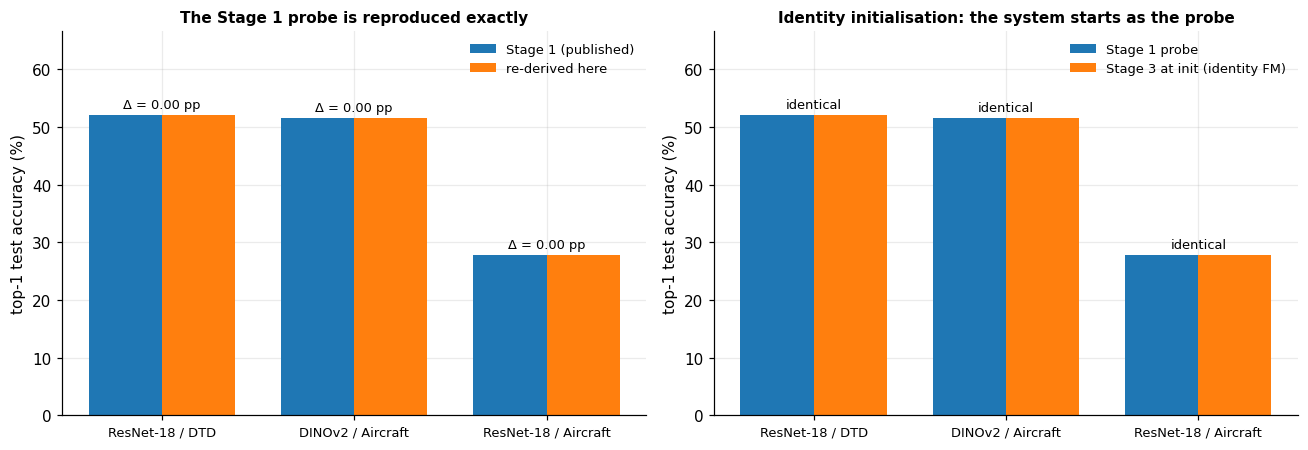

In [10]:
combo_label = {("resnet18", "DTD"): "ResNet-18 / DTD",
               ("dinov2", "FGVC-Aircraft"): "DINOv2 / Aircraft",
               ("resnet18", "FGVC-Aircraft"): "ResNet-18 / Aircraft"}
order = [combo_label[c] for c in COMBOS]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# (a) Stage 1 reproduction
ax = axes[0]
agg = (verify.assign(combo=[combo_label[(e, d)] for e, d in zip(verify.encoder, verify.dataset)])
             .groupby("combo")[["stage1_test_acc", "rederived_test_acc"]].mean()
             .reindex(order) * 100)
xs = np.arange(len(order))
ax.bar(xs - 0.19, agg["stage1_test_acc"], 0.38, label="Stage 1 (published)")
ax.bar(xs + 0.19, agg["rederived_test_acc"], 0.38, label="re-derived here")
for i, v in enumerate(agg["rederived_test_acc"]):
    ax.annotate("Δ = 0.00 pp", (i, v + 1.2), ha="center", fontsize=8.5)
ax.set_xticks(xs); ax.set_xticklabels(order, fontsize=8.5)
ax.set_ylabel("top-1 test accuracy (%)")
ax.set_ylim(0, max(agg.max()) * 1.28)
ax.set_title("The Stage 1 probe is reproduced exactly", fontsize=10)
ax.legend(fontsize=8.5)

# (b) identity init
ax = axes[1]
agg2 = (identity.assign(combo=[combo_label[(e, d)] for e, d in zip(identity.encoder, identity.dataset)])
                .groupby("combo")[["probe_acc", "stage3_at_init_acc"]].mean()
                .reindex(order) * 100)
ax.bar(xs - 0.19, agg2["probe_acc"], 0.38, label="Stage 1 probe")
ax.bar(xs + 0.19, agg2["stage3_at_init_acc"], 0.38, label="Stage 3 at init (identity FM)")
for i, v in enumerate(agg2["stage3_at_init_acc"]):
    ax.annotate("identical", (i, v + 1.2), ha="center", fontsize=8.5)
ax.set_xticks(xs); ax.set_xticklabels(order, fontsize=8.5)
ax.set_ylabel("top-1 test accuracy (%)")
ax.set_ylim(0, max(agg2.max()) * 1.28)
ax.set_title("Identity initialisation: the system starts as the probe", fontsize=10)
ax.legend(fontsize=8.5)

fig.tight_layout()
art.figure(fig, "setup_verification")
plt.show()

  saved plot  -> plots/why_no_normalization.png


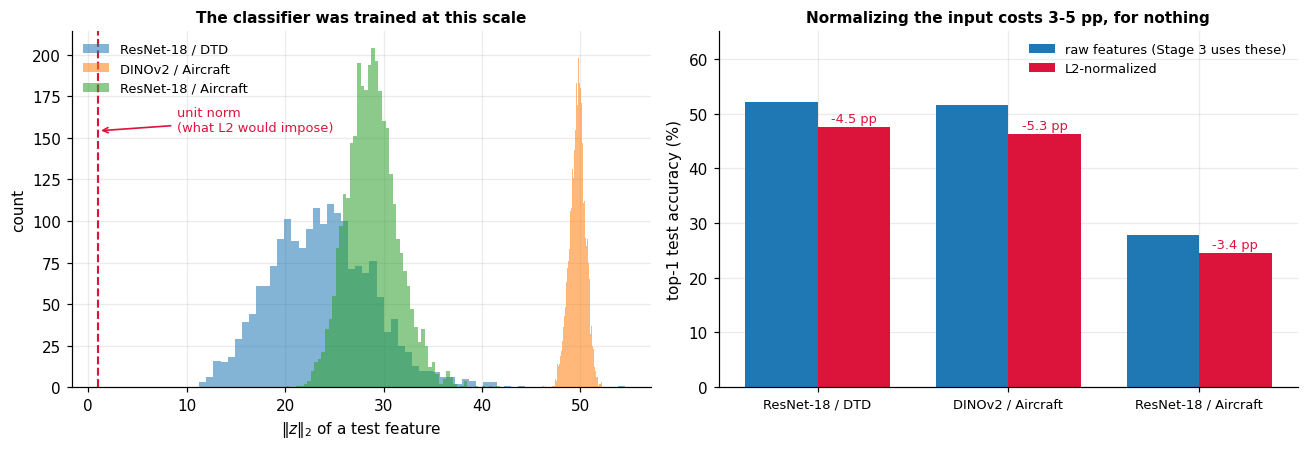

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# (a) feature norms - why normalization is not free here
ax = axes[0]
for encoder, dataset in COMBOS:
    norms = load_features(encoder, dataset, "test").features.norm(dim=1).numpy()
    ax.hist(norms, bins=60, alpha=0.55, label=combo_label[(encoder, dataset)])
ax.axvline(1.0, color="crimson", ls="--", lw=1.4)
ax.annotate("unit norm\n(what L2 would impose)", (1.0, ax.get_ylim()[1] * 0.72),
            xytext=(9, ax.get_ylim()[1] * 0.72), fontsize=8.5, color="crimson",
            arrowprops=dict(arrowstyle="->", color="crimson", lw=1.1))
ax.set_xlabel(r"$\|z\|_2$ of a test feature")
ax.set_ylabel("count")
ax.set_title("The classifier was trained at this scale", fontsize=10)
ax.legend(fontsize=8.5)

# (b) the cost of normalizing
ax = axes[1]
agg3 = (l2.assign(combo=[combo_label[(e, d)] for e, d in zip(l2.encoder, l2.dataset)])
          .groupby("combo")[["raw_acc", "l2_normalized_acc"]].mean().reindex(order) * 100)
ax.bar(xs - 0.19, agg3["raw_acc"], 0.38, label="raw features (Stage 3 uses these)")
ax.bar(xs + 0.19, agg3["l2_normalized_acc"], 0.38, label="L2-normalized", color="crimson")
for i, (r, u) in enumerate(zip(agg3["raw_acc"], agg3["l2_normalized_acc"])):
    ax.annotate(f"{u - r:+.1f} pp", (i + 0.19, u + 0.9), ha="center", fontsize=8.5,
                color="crimson")
ax.set_xticks(xs); ax.set_xticklabels(order, fontsize=8.5)
ax.set_ylabel("top-1 test accuracy (%)")
ax.set_ylim(0, max(agg3.max()) * 1.25)
ax.set_title("Normalizing the input costs 3-5 pp, for nothing", fontsize=10)
ax.legend(fontsize=8.5)

fig.tight_layout()
art.figure(fig, "why_no_normalization")
plt.show()

## 7 · Saving the frozen classifiers

Everything downstream loads this one file, so the classifier cannot be accidentally
retrained — or retrained differently — in a later notebook.

In [12]:
payload = {
    "classifiers": classifiers,
    "curves": curves,
    "protocol": {"K": K_SHOT, "seeds": list(SEEDS), "T": T_STEPS,
                 "combos": [list(c) for c in COMBOS],
                 "probe_config": ProbeConfig().as_dict(),
                 "normalize_features": False},
    "verification": {
        "max_abs_delta_pp_vs_stage1": float(verify["abs_delta_pp"].max()),
        "predictions_identical": bool(verify["predictions_identical"].all()),
        "identity_init_exact": bool(identity["features_bit_identical"].all()),
    },
}
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
torch.save(payload, RESULTS_ROOT / "frozen_classifiers.pt")

size_kb = (RESULTS_ROOT / "frozen_classifiers.pt").stat().st_size / 1024
print(f"saved {len(classifiers)} frozen classifiers -> "
      f"{RESULTS_ROOT / 'frozen_classifiers.pt'}  ({size_kb:.0f} KB)")

saved 9 frozen classifiers -> C:\Users\<user>\Project in Computer Vision\ProjectInComputerVision\Stage_3\results\frozen_classifiers.pt  (1389 KB)


In [13]:
art.manifest()
print()
print("Step 01 complete.\n")
print(f"  {len(classifiers)} classifiers recovered and frozen "
      f"({len(COMBOS)} combinations x {len(SEEDS)} seeds, K = {K_SHOT})")
print(f"  reproduction vs Stage 1      : max |delta| = {verify['abs_delta_pp'].max():.2e} pp, "
      f"predictions identical")
print(f"  identity initialisation      : z_hat == z bit-for-bit, accuracy unchanged")
print(f"  normalization decision       : raw features "
      f"({l2_summary['cost_pp'].min():.1f} to {l2_summary['cost_pp'].max():.1f} pp if normalized)")
print(f"  T = {T_STEPS} Euler steps, fixed for all of Stage 3")
print("\nNext: step 02 trains the end-to-end rolled-out classification objective.")

7 artefacts in C:\Users\<user>\Project in Computer Vision\ProjectInComputerVision\Stage_3\Work\01_setup_classifier

Step 01 complete.

  9 classifiers recovered and frozen (3 combinations x 3 seeds, K = 10)
  reproduction vs Stage 1      : max |delta| = 0.00e+00 pp, predictions identical
  identity initialisation      : z_hat == z bit-for-bit, accuracy unchanged
  normalization decision       : raw features (-5.3 to -3.4 pp if normalized)
  T = 4 Euler steps, fixed for all of Stage 3

Next: step 02 trains the end-to-end rolled-out classification objective.
